# MÔ TẢ HÌNH ẢNH VỚI TẬP DỮ LIỆU FLICKR30K

## 1. Giới thiệu tập dữ liệu
**Flickr30k** là bộ dữ liệu đa phương thức tiêu chuẩn cho bài toán mô tả hình ảnh.
* Quy mô: 31,783 hình ảnh thực tế.
* Nội dung: Mỗi ảnh đi kèm 5 câu chú thích (captions) do con người viết.
* Mục tiêu: Giúp mô hình học cách liên kết giữa đặc trưng hình ảnh và ngôn ngữ tự nhiên.

## 2. Phương pháp nghiên cứu
Quy trình nghiên cứu tập trung vào việc chuẩn bị dữ liệu đa phương thức thông qua 4 bước cốt lõi:

* **Phân tích đặc điểm (EDA)**: Thống kê tần suất từ vựng (thực thể/hành động) và phân phối độ dài câu để xác định ngưỡng `MAX_SEQ_LEN` tối ưu cho mô hình.
* **Tiền xử lý văn bản**: Làm sạch nhiễu (ký tự đặc biệt, số), chuẩn hóa chữ thường và thêm các token điều hướng (`startseq`, `endseq`) để định nghĩa biên cho Decoder.
* **Mã hóa dữ liệu (Vocabulary)**: Xây dựng bộ từ điển dựa trên ngưỡng tần suất (Frequency Threshold) và chuyển đổi các chuỗi văn bản thành các dãy số nguyên (Tensors).
* **Thiết lập & Phân tách**: Ghép cặp Ảnh-Văn bản theo tỷ lệ 1:5 và chia tập Train/Val (9/1) dựa trên tên ảnh để tránh rò rỉ thông tin và đảm bảo tính khách quan.

## 3. Hiện thực hóa quy trình (Implementation)

### 3.1. Tải và Cấu trúc hóa dữ liệu (Setup & Data Loading)

In [7]:
import kagglehub
import os

# Download the latest version
path = kagglehub.dataset_download("hsankesara/flickr-image-dataset")

# Scan the directory to find the exact path of results.csv
csv_path = ""
for root, dirs, files in os.walk(path):
    if "results.csv" in files:
        csv_path = os.path.join(root, "results.csv")
        break

if csv_path:
    print(f"File found at: {csv_path}")
else:
    print("File results.csv not found. Please check the extraction process.")

File found at: /root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1/flickr30k_images/results.csv


In [8]:
import pandas as pd

# Load data with a delimiter fix
# Use on_bad_lines='skip' for Pandas 2.0+ compatibility
df = pd.read_csv(csv_path, sep='|', on_bad_lines='skip')

# Clean column names (remove leading/trailing spaces)
df.columns = [col.strip() for col in df.columns]

# Drop any rows with missing values
df = df.dropna()

print(f"Dataset successfully loaded with {len(df)} samples.")
print(df.head())

Dataset successfully loaded with 158914 samples.
       image_name comment_number  \
0  1000092795.jpg              0   
1  1000092795.jpg              1   
2  1000092795.jpg              2   
3  1000092795.jpg              3   
4  1000092795.jpg              4   

                                             comment  
0   Two young guys with shaggy hair look at their...  
1   Two young , White males are outside near many...  
2   Two men in green shirts are standing in a yard .  
3       A man in a blue shirt standing in a garden .  
4            Two friends enjoy time spent together .  


### 3.2. Phân tích Dữ liệu Khám phá (EDA)

#### 3.2.1. Thống kê tần suất từ vựng (Word Frequency)
Xác định các thực thể và hành động xuất hiện nhiều nhất trong tập dữ liệu để hiểu về nội dung hình ảnh chủ đạo.

/tmp/ipykernel_510/3889252798.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='magma')


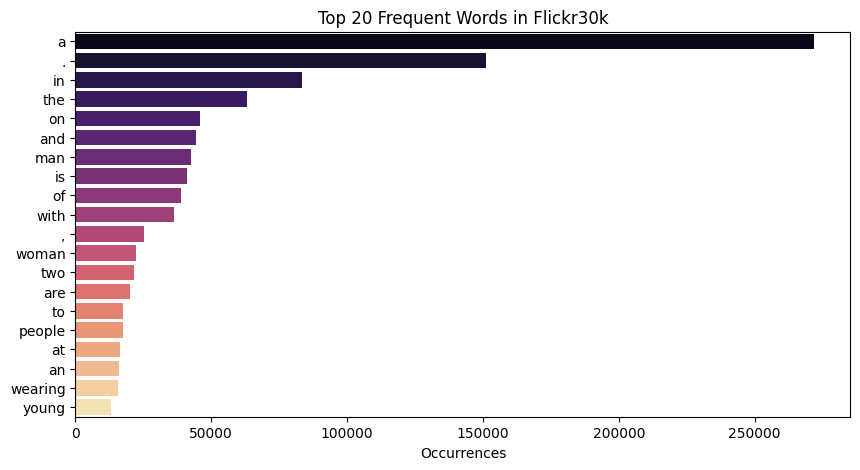

In [9]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Flatten all captions into a single list of lowercase words
all_words = " ".join(df['comment'].astype(str)).lower().split()
word_counts = Counter(all_words)
words, counts = zip(*word_counts.most_common(20))

# Plot the 20 most frequent words
plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words), palette='magma')
plt.title('Top 20 Frequent Words in Flickr30k')
plt.xlabel('Occurrences')
plt.show()

#### 3.2.2. Phân tích độ dài câu (Caption Length)
Đánh giá độ dài của các câu mô tả để xác định ngưỡng cắt (cutoff) tối ưu, giúp cân bằng giữa việc giữ thông tin và hiệu quả tính toán.

Recommended MAX_SEQ_LEN: 23


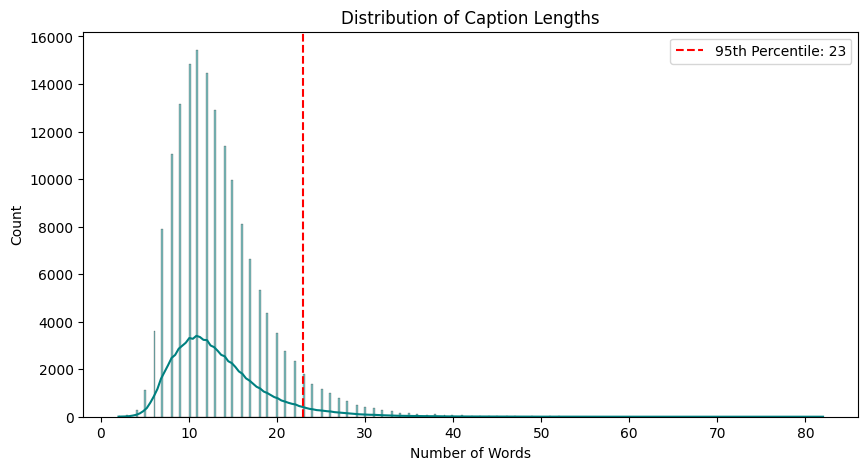

In [11]:
# Calculate word count for each caption entry
df['word_count'] = df['comment'].apply(lambda x: len(str(x).split()))

# Calculate the 95th percentile for optimal sequence length
p95 = int(df['word_count'].quantile(0.95))
print(f"Recommended MAX_SEQ_LEN: {p95}")

# Plotting the length distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], kde=True, color='teal')
plt.axvline(p95, color='red', linestyle='--', label=f'95th Percentile: {p95}')
plt.title('Distribution of Caption Lengths')
plt.xlabel('Number of Words')
plt.legend()
plt.show()

#### 3.2.3. Kiểm tra chất lượng và Từ hiếm (Rare Word & Quality Check)
Xác định số lượng từ hiếm (chỉ xuất hiện 1 lần) để quyết định ngưỡng lọc từ vựng, đồng thời kiểm tra tính toàn vẹn của dữ liệu (mỗi ảnh đủ 5 captions).

In [12]:
# Identify rare words that appear only once
rare_words = [word for word, count in word_counts.items() if count == 1]
print(f"Number of rare words (appearing once): {len(rare_words)}")

# Quality check: Distribution of captions per image
caption_counts = df['image_name'].value_counts()
print(f"Standard captions per image (expected 5): \n{caption_counts.value_counts()}")

Number of rare words (appearing once): 7821
Standard captions per image (expected 5): 
count
5    31782
4        1
Name: count, dtype: int64


### 3.3. Tiền xử lý văn bản (Text Preprocessing)

#### 3.3.1. Làm sạch và Chuẩn hóa (Text Cleaning)
Sử dụng biểu thức chính quy (Regular Expression) để loại bỏ toàn bộ dấu câu và số, chỉ giữ lại các ký tự chữ cái. Toàn bộ văn bản được đưa về chữ thường (lowercase) để đảm bảo tính đồng nhất.

In [15]:
import re

def clean_text(text):
    # Convert to string and lowercase
    text = str(text).lower()

    # Remove punctuation and numbers using regex
    # Only keep alphabetic characters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra whitespaces
    text = " ".join(text.split())
    return text

# Apply the cleaning function to create 'clean_caption' column
df['clean_caption'] = df['comment'].apply(clean_text)

# Check the result before building vocabulary
print(f"Raw: {df['comment'].iloc[0]}")
print(f"Cleaned: {df['clean_caption'].iloc[0]}")

Raw:  Two young guys with shaggy hair look at their hands while hanging out in the yard .
Cleaned: two young guys with shaggy hair look at their hands while hanging out in the yard


#### 3.3.2. Token hóa (Tokenization)
Sau khi đã có các câu "sạch", nhóm đã tách chúng thành các đơn vị từ (tokens). Đây là đơn vị nhỏ nhất mà mô hình sẽ học.

In [16]:
# Create a list of tokens for each cleaned caption
# This list will be the input for the build_vocabulary method
df['tokens'] = df['clean_caption'].apply(lambda x: x.split())

# Quality Check: Sample of tokens
print(f"Tokens sample: {df['tokens'].iloc[0]}")

Tokens sample: ['two', 'young', 'guys', 'with', 'shaggy', 'hair', 'look', 'at', 'their', 'hands', 'while', 'hanging', 'out', 'in', 'the', 'yard']


#### 3.3.3. Xây dựng Từ điển (Vocabulary Building Class)
Khởi tạo lớp `Vocabulary` để thiết lập ánh xạ hai chiều giữa từ vựng và chỉ số số nguyên. Lớp này tự động thêm các thẻ điều hướng chuỗi (SOS, EOS) và xử lý các từ hiếm thông qua ngưỡng `freq_threshold`.

Các logic thực hiện:
* Xử lý từ hiếm: Việc đặt `freq_threshold=2` giúp loại bỏ khoảng 7821 từ chỉ xuất hiện một lần (đã tìm thấy ở EDA). Điều này giúp giảm nhiễu và làm mô hình nhẹ hơn, tập trung vào những từ có ý nghĩa thống kê cao.
* Token điều hướng: `<SOS>` và `<EOS>` là bắt buộc cho các mô hình sinh (Generative Models). Chúng đóng vai trò là "cột mốc" để mô hình biết nơi bắt đầu và nơi kết thúc một ý tưởng.
* Tính toàn vẹn: Việc sử dụng `<UNK>` đảm bảo rằng chương trình sẽ không bị lỗi khi gặp các từ lạ trong tương lai (tập Validation/Test).

In [17]:
from collections import Counter

class Vocabulary:
    def __init__(self, freq_threshold=2):
        # freq_threshold: Minimum frequency to include a word in the dictionary
        self.freq_threshold = freq_threshold

        # Reserved special tokens for sequence control
        self.PAD_token = 0 # Padding token
        self.SOS_token = 1 # Start of sentence token
        self.EOS_token = 2 # End of sentence token
        self.UNK_token = 3 # Unknown/Rare word token

        # Bi-directional mapping initialization
        self.word2idx = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.idx = 4

    def build_vocabulary(self, sentence_list):
        # Count word frequencies across the provided corpus
        frequencies = Counter()
        for sentence in sentence_list:
            for word in str(sentence).split():
                frequencies[word] += 1

        # Register words that meet the frequency criteria
        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.word2idx[word] = self.idx
                self.idx2word[self.idx] = word
                self.idx += 1

    def numericalize(self, text):
        # Convert a text string into a list of integer indices
        tokenized_text = str(text).split()

        # Encapsulate indices with SOS and EOS tokens for the Decoder
        return [self.SOS_token] + \
               [self.word2idx.get(word, self.UNK_token) for word in tokenized_text] + \
               [self.EOS_token]

# Initialization and processing using the cleaned captions
# Using clean_caption from your previous text cleaning step
vocab = Vocabulary(freq_threshold=2)
vocab.build_vocabulary(df['clean_caption'].tolist())

print(f"Total vocabulary size (frequency >= 2): {len(vocab.word2idx)}")

# Demonstration of Numericalization on the first sample
sample_text = df['clean_caption'].iloc[0]
numericalized_sample = vocab.numericalize(sample_text)

print(f"Sample Text: {sample_text}")
print(f"Numericalized Sequence: {numericalized_sample}")

Total vocabulary size (frequency >= 2): 12368
Sample Text: two young guys with shaggy hair look at their hands while hanging out in the yard
Numericalized Sequence: [1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2]


#### 3.3.4. Số hóa văn bản (Numericalization)
Chúng ta sử dụng đối tượng vocab đã xây dựng để chuyển đổi chuỗi văn bản sạch thành danh sách các con số. Kết quả này bắt buộc phải được lưu vào cột `num_seq` để các bước sau (như Padding) có thể tìm thấy dữ liệu.

In [19]:
# Create the 'num_seq' column by applying the numericalize method
# This is the step that was likely missing or failed in your previous run
df['num_seq'] = df['clean_caption'].apply(lambda x: vocab.numericalize(x))

# Quick check: Verify that the column now exists and contains data
print("Column check:")
print(df[['clean_caption', 'num_seq']].head())

Column check:
                                       clean_caption  \
0  two young guys with shaggy hair look at their ...   
1  two young white males are outside near many bu...   
2     two men in green shirts are standing in a yard   
3         a man in a blue shirt standing in a garden   
4              two friends enjoy time spent together   

                                             num_seq  
0  [1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...  
1           [1, 4, 5, 20, 21, 22, 23, 24, 25, 26, 2]  
2      [1, 4, 27, 17, 28, 29, 22, 30, 17, 31, 19, 2]  
3     [1, 31, 32, 17, 31, 33, 34, 30, 17, 31, 35, 2]  
4                      [1, 4, 36, 37, 38, 39, 40, 2]  


#### 3.3.4. Lấp đầy chuỗi (Sequence Padding)
Trong thực tế, các câu mô tả có độ dài rất khác nhau. Tuy nhiên, để máy tính có thể xử lý hàng loạt câu cùng một lúc (Batch Processing) nhằm tăng tốc độ tính toán, chúng ta cần đưa tất cả về cùng một độ dài duy nhất.
Chúng ta chọn độ dài chuẩn là p95 (ngưỡng bao phủ 95\% dữ liệu).

* Nếu câu dài hơn p95: Ta sẽ cắt bớt (Truncating).
* Nếu câu ngắn hơn p95: Ta thêm các số 0 (gọi là `<PAD>`) vào phía sau. Những số 0 này đóng vai trò như "vật lấp chỗ trống", giúp các khối dữ liệu trở nên vuông vức nhưng không làm thay đổi ý nghĩa của câu gốc.

In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# MAX_SEQ_LEN is the p95 value from EDA
# Now we access 'num_seq' which was created in the previous block
df['padded_seq'] = list(pad_sequences(df['num_seq'], maxlen=MAX_SEQ_LEN, padding='post'))

print(f"Padding successful. Sequence length: {len(df['padded_seq'].iloc[0])}")

Padding successful. Sequence length: 23


#### 3.3.5. Ghép cặp Ảnh - Chú thích (Image-Caption Pairing)
Thiết lập mối liên kết giữa đường dẫn tệp ảnh vật lý và chuỗi văn bản đã được số hóa tương ứng. Đây là bước chuẩn bị cấu trúc dữ liệu cuối cùng để bộ nạp dữ liệu (Data Loader) có thể truy xuất đồng thời cả đặc trưng thị giác và ngôn ngữ.

In [22]:
import os

# Define the absolute path to the local image repository
IMAGE_DIR = "/root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1/flickr30k_images/flickr30k_images/"

# Map image filenames to their absolute paths in the filesystem
df['image_path'] = df['image_name'].apply(lambda x: os.path.join(IMAGE_DIR, x))

# Quality control check for a single data pair
print(f"Sample Image Path: {df['image_path'].iloc[0]}")
print(f"Sample Padded Sequence: {df['padded_seq'].iloc[0][:10]}...")

Sample Image Path: /root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1/flickr30k_images/flickr30k_images/1000092795.jpg
Sample Padded Sequence: [ 1  4  5  6  7  8  9 10 11 12]...


#### 3.3.6. Phân tách tập dữ liệu (Data Splitting)
Chia dữ liệu thành tập **Train (90%)** và **Validation (10%)**. Việc phân tách được thực hiện dựa trên danh sách các ảnh duy nhất để đảm bảo rằng toàn bộ các mô tả của cùng một hình ảnh sẽ chỉ thuộc về một tập dữ liệu duy nhất, ngăn chặn hiện tượng "rò rỉ thông tin" (data leakage) giữa quá trình huấn luyện và đánh giá.

In [23]:
from sklearn.model_selection import train_test_split

# Partitioning based on unique image IDs to ensure strict separation
unique_images = df['image_name'].unique()
train_ids, val_ids = train_test_split(unique_images, test_size=0.1, random_state=42)

# Construct final DataFrames for model ingestion
train_df = df[df['image_name'].isin(train_ids)]
val_df = df[df['image_name'].isin(val_ids)]

print(f"--- Data Distribution Summary ---")
print(f"Training set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")

--- Data Distribution Summary ---
Training set: 143019 samples
Validation set: 15895 samples
